#   Credit Card Default Prediction


importing essential modules


In [484]:
import numpy as np
import pandas as pd

We load the file train_dataset_final1.csv and show the first few rows to get an idea of what the data looks like.

In [485]:
credit_df =  pd.read_csv("train_dataset_final1.csv")
df = pd.read_csv("train_dataset_final1.csv")
df.head()

,Customer_ID,marriage,sex,education,LIMIT_BAL,age,pay_0,pay_2,pay_3,pay_4,...,Bill_amt6,pay_amt1,pay_amt2,pay_amt3,pay_amt4,pay_amt5,pay_amt6,AVG_Bill_amt,PAY_TO_BILL_ratio,next_month_default
0,5017,2,0,2,60000,25.0,2,2,2,0,...,20750.63,2000.21,0.00,1134.85,1821.78,1500.03,1500.24,41511.50,0.03,0
1,5018,2,1,1,290000,24.0,0,0,-2,-2,...,1350.30,0.00,0.17,0.00,2700.10,0.00,1349.72,2534.50,0.27,0
2,5019,1,0,2,180000,63.0,0,0,0,0,...,52991.51,2086.94,2199.99,1845.66,2000.35,1923.00,1999.78,50422.00,0.04,0
3,5020,1,1,2,210000,43.0,0,0,0,0,...,76945.47,3348.07,3380.91,3400.45,2683.97,2744.00,2892.10,86229.50,0.04,0
4,5021,2,0,1,280000,32.0,-2,-2,-2,-2,...,1.35,999.78,3186.27,45027.78,2100.09,0.01,0.27,11814.33,0.72,0


# Data Preprocessing

In [486]:
df.shape

(25247, 27)

We remove the Customer_ID column since it's just an identifier and doesn't help in model training.

In [487]:
df.drop('Customer_ID',axis='columns',inplace = True)
df

,marriage,sex,education,LIMIT_BAL,age,pay_0,pay_2,pay_3,pay_4,pay_5,...,Bill_amt6,pay_amt1,pay_amt2,pay_amt3,pay_amt4,pay_amt5,pay_amt6,AVG_Bill_amt,PAY_TO_BILL_ratio,next_month_default
0,2,0,2,60000,25.0,2,2,2,0,0,...,20750.63,2000.21,0.00,1134.85,1821.78,1500.03,1500.24,41511.50,0.03,0
1,2,1,1,290000,24.0,0,0,-2,-2,-1,...,1350.30,0.00,0.17,0.00,2700.10,0.00,1349.72,2534.50,0.27,0
2,1,0,2,180000,63.0,0,0,0,0,0,...,52991.51,2086.94,2199.99,1845.66,2000.35,1923.00,1999.78,50422.00,0.04,0
3,1,1,2,210000,43.0,0,0,0,0,0,...,76945.47,3348.07,3380.91,3400.45,2683.97,2744.00,2892.10,86229.50,0.04,0
4,2,0,1,280000,32.0,-2,-2,-2,-2,-2,...,1.35,999.78,3186.27,45027.78,2100.09,0.01,0.27,11814.33,0.72,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25242,1,1,2,90000,33.0,0,0,0,0,2,...,90042.87,2800.18,3999.97,8000.09,5347.85,3699.98,3128.06,82312.50,0.05,0
25243,1,0,2,60000,49.0,0,0,0,0,0,...,19204.07,22000.17,2187.56,2501.13,2512.09,4004.89,2604.22,41371.67,0.14,1
25244,2,0,1,120000,31.0,-1,-1,-1,-1,-1,...,9834.64,1315.83,1315.60,533.08,4116.08,9834.10,7100.12,3071.83,1.31,1
25245,1,1,4,390000,40.0,0,0,0,0,0,...,199013.32,7636.03,5652.86,5544.67,5532.37,5859.09,6818.14,197278.83,0.03,0


We check how many missing (null) values are in each column to see if any data needs cleaning.

In [488]:
df.isnull().sum()

marriage                0
sex                     0
education               0
LIMIT_BAL               0
age                   126
pay_0                   0
pay_2                   0
pay_3                   0
pay_4                   0
pay_5                   0
pay_6                   0
Bill_amt1               0
Bill_amt2               0
Bill_amt3               0
Bill_amt4               0
Bill_amt5               0
Bill_amt6               0
pay_amt1                0
pay_amt2                0
pay_amt3                0
pay_amt4                0
pay_amt5                0
pay_amt6                0
AVG_Bill_amt            0
PAY_TO_BILL_ratio       0
next_month_default      0
dtype: int64

In [489]:
df.describe()

,marriage,sex,education,LIMIT_BAL,age,pay_0,pay_2,pay_3,pay_4,pay_5,...,Bill_amt6,pay_amt1,pay_amt2,pay_amt3,pay_amt4,pay_amt5,pay_amt6,AVG_Bill_amt,PAY_TO_BILL_ratio,next_month_default
count,25247.000000,25247.000000,25247.000000,25247.000000,25121.000000,25247.000000,25247.000000,25247.000000,25247.000000,25247.000000,...,25247.000000,25247.000000,2.524700e+04,25247.000000,25247.000000,25247.000000,25247.000000,25247.000000,25247.000000,25247.000000
mean,1.551907,0.604111,1.852101,168342.060443,35.438199,-0.042857,-0.159544,-0.190359,-0.241415,-0.282568,...,38806.221029,5718.624966,6.047352e+03,5288.910651,4865.960834,4906.766828,5270.499287,44859.647485,0.362962,0.190399
std,0.522629,0.489050,0.797379,129892.784807,9.174998,1.099315,1.173990,1.172636,1.146753,1.114213,...,59182.792531,16806.842125,2.400962e+04,17851.879609,15979.116544,15860.726852,17960.816915,62819.226119,5.047206,0.392624
min,0.000000,0.000000,0.000000,10000.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,-56043.170000,-546.930000,0.000000
25%,1.000000,0.000000,1.000000,50000.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,1241.710000,999.985000,9.219100e+02,399.990000,300.150000,262.365000,130.070000,4858.670000,0.040000,0.000000
50%,2.000000,1.000000,2.000000,140000.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,17102.580000,2145.020000,2.026830e+03,1844.300000,1500.100000,1513.790000,1500.040000,21102.830000,0.090000,0.000000
75%,2.000000,1.000000,2.000000,240000.000000,41.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,49245.195000,5031.150000,5.000190e+03,4600.640000,4014.990000,4099.890000,4018.780000,57136.580000,0.590000,0.000000
max,3.000000,1.000000,6.000000,1000000.000000,79.000000,8.000000,8.000000,8.000000,7.000000,7.000000,...,961663.620000,873551.980000,1.684259e+06,896040.150000,621000.080000,426529.180000,528666.150000,877313.830000,205.380000,1.000000


We fill the missing values in the age column using the median age. This helps keep the data consistent without adding any bias from extreme values.

In [490]:
df['age'].fillna(df['age'].median(),inplace = True)
df

,marriage,sex,education,LIMIT_BAL,age,pay_0,pay_2,pay_3,pay_4,pay_5,...,Bill_amt6,pay_amt1,pay_amt2,pay_amt3,pay_amt4,pay_amt5,pay_amt6,AVG_Bill_amt,PAY_TO_BILL_ratio,next_month_default
0,2,0,2,60000,25.0,2,2,2,0,0,...,20750.63,2000.21,0.00,1134.85,1821.78,1500.03,1500.24,41511.50,0.03,0
1,2,1,1,290000,24.0,0,0,-2,-2,-1,...,1350.30,0.00,0.17,0.00,2700.10,0.00,1349.72,2534.50,0.27,0
2,1,0,2,180000,63.0,0,0,0,0,0,...,52991.51,2086.94,2199.99,1845.66,2000.35,1923.00,1999.78,50422.00,0.04,0
3,1,1,2,210000,43.0,0,0,0,0,0,...,76945.47,3348.07,3380.91,3400.45,2683.97,2744.00,2892.10,86229.50,0.04,0
4,2,0,1,280000,32.0,-2,-2,-2,-2,-2,...,1.35,999.78,3186.27,45027.78,2100.09,0.01,0.27,11814.33,0.72,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25242,1,1,2,90000,33.0,0,0,0,0,2,...,90042.87,2800.18,3999.97,8000.09,5347.85,3699.98,3128.06,82312.50,0.05,0
25243,1,0,2,60000,49.0,0,0,0,0,0,...,19204.07,22000.17,2187.56,2501.13,2512.09,4004.89,2604.22,41371.67,0.14,1
25244,2,0,1,120000,31.0,-1,-1,-1,-1,-1,...,9834.64,1315.83,1315.60,533.08,4116.08,9834.10,7100.12,3071.83,1.31,1
25245,1,1,4,390000,40.0,0,0,0,0,0,...,199013.32,7636.03,5652.86,5544.67,5532.37,5859.09,6818.14,197278.83,0.03,0


 marriage Marital status of the customer (1 = Married, 2 = Single, 3 = Others)
- Gender of the customer (1 = Male, 0 = Female)
- Education level (1 = Graduate School, 2 = University, 3 = High School, 4 = Others)
- Age of the customer (in years)

Checking the unique values in marriage, sex, education, cloumns

In [491]:
col = ['marriage',"education"]

for i in col:
    print(f'{i} : {df[i].unique()}')

marriage : [2 1 3 0]
education : [2 1 3 4 5 6 0]


We convert the sex, marriage, and education columns into numeric format using one-hot encoding. The drop_first=True option avoids duplicate information by dropping the first category from each column.

In [492]:
df['marriage']=df['marriage'].replace({0:3})
df['education'] = df['education'].replace({0:4,5:4,6:4})

for i in col:
    print(f'{i} : {df[i].unique()}')

del col
# df = pd.get_dummies(df, columns=['sex', 'marriage', 'education'], drop_first=True)

marriage : [2 1 3]
education : [2 1 3 4]


In [493]:
colums = df.columns
cat_colms = ['marriage','education']
num_colms = [i for i in colums if i not in cat_colms]

df = pd.get_dummies(df,columns= cat_colms ,drop_first = True ).astype(int)


To keep extreme values from affecting the model, we apply the IQR (Interquartile Range) method to cap outliers. Each selected column is adjusted so its values fall within a reasonable range based on its distribution.

In [494]:
def outlier_solution(df,columns):
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        iqr = Q3-Q1
        lower = Q1 - 1.5*iqr
        upper = Q3 + 1.5*iqr
        df[col] = df[col].clip(lower,upper)
    return df
columns= ["age", "LIMIT_BAL",
    "Bill_amt1", "Bill_amt2", "Bill_amt3", "Bill_amt4", "Bill_amt5", "Bill_amt6",
    "pay_amt1", "pay_amt2", "pay_amt3", "pay_amt4", "pay_amt5", "pay_amt6",
    "AVG_Bill_amt"]
df = outlier_solution(df,columns)
df

,sex,LIMIT_BAL,age,pay_0,pay_2,pay_3,pay_4,pay_5,pay_6,Bill_amt1,...,pay_amt5,pay_amt6,AVG_Bill_amt,PAY_TO_BILL_ratio,next_month_default,marriage_2,marriage_3,education_2,education_3,education_4
0,0,60000,25.0,2,2,2,0,0,0,60323,...,1500.0,1500.0,41511.00,0,0,1,0,1,0,0
1,1,290000,24.0,0,0,-2,-2,-1,0,11157,...,0.0,1349.0,2534.00,0,0,1,0,0,0,0
2,0,180000,60.5,0,0,0,0,0,0,47930,...,1923.0,1999.0,50422.00,0,0,0,0,1,0,0
3,1,210000,43.0,0,0,0,0,0,0,91152,...,2744.0,2892.0,86229.00,0,0,0,0,1,0,0
4,0,280000,32.0,-2,-2,-2,-2,-2,-2,19666,...,0.0,0.0,11814.00,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25242,1,90000,33.0,0,0,0,0,2,2,75452,...,3699.0,3128.0,82312.00,0,0,0,0,1,0,0
25243,0,60000,49.0,0,0,0,0,0,0,59578,...,4004.0,2604.0,41371.00,0,1,0,0,1,0,0
25244,0,120000,31.0,-1,-1,-1,-1,-1,-1,1315,...,9834.0,7100.0,3071.00,1,1,1,0,0,0,0
25245,1,390000,40.0,0,0,0,0,0,0,163031,...,5859.0,6818.0,135552.25,0,0,0,0,0,0,1


In [495]:
df['PAY_TO_BILL_ratio'].describe()

count    25247.000000
mean         0.148018
std          5.024064
min       -546.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        205.000000
Name: PAY_TO_BILL_ratio, dtype: float64

We use the IQR method to cap unusually high values in the PAY_TO_BILL_ratio column. Since negative values don't make sense in this context, we also set the lower limit to 0. This helps in keeping the values meaningful and within a reasonable range for analysis.

In [496]:
df

,sex,LIMIT_BAL,age,pay_0,pay_2,pay_3,pay_4,pay_5,pay_6,Bill_amt1,...,pay_amt5,pay_amt6,AVG_Bill_amt,PAY_TO_BILL_ratio,next_month_default,marriage_2,marriage_3,education_2,education_3,education_4
0,0,60000,25.0,2,2,2,0,0,0,60323,...,1500.0,1500.0,41511.00,0,0,1,0,1,0,0
1,1,290000,24.0,0,0,-2,-2,-1,0,11157,...,0.0,1349.0,2534.00,0,0,1,0,0,0,0
2,0,180000,60.5,0,0,0,0,0,0,47930,...,1923.0,1999.0,50422.00,0,0,0,0,1,0,0
3,1,210000,43.0,0,0,0,0,0,0,91152,...,2744.0,2892.0,86229.00,0,0,0,0,1,0,0
4,0,280000,32.0,-2,-2,-2,-2,-2,-2,19666,...,0.0,0.0,11814.00,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25242,1,90000,33.0,0,0,0,0,2,2,75452,...,3699.0,3128.0,82312.00,0,0,0,0,1,0,0
25243,0,60000,49.0,0,0,0,0,0,0,59578,...,4004.0,2604.0,41371.00,0,1,0,0,1,0,0
25244,0,120000,31.0,-1,-1,-1,-1,-1,-1,1315,...,9834.0,7100.0,3071.00,1,1,1,0,0,0,0
25245,1,390000,40.0,0,0,0,0,0,0,163031,...,5859.0,6818.0,135552.25,0,0,0,0,0,0,1


we check basic statistics (like mean, min, max, and quartiles) of the AVG_Bill_amt column to understand the typical billing amount and identify any unusual values.

In [497]:
df['AVG_Bill_amt'].describe()

count     25247.000000
mean      38671.440904
std       42987.133291
min      -56043.000000
25%        4858.500000
50%       21102.000000
75%       57136.000000
max      135552.250000
Name: AVG_Bill_amt, dtype: float64

# Feature engineering 

Create two engineered features. The first one is "age_group," which can be a valuable feature for analysis. It is possible that adults are more prevalent in the default segment, but we need to investigate this further. We will conduct a statistical visualization to see how the age group contributes to default prediction. The second one is credit utilization, which shows how much a customer is using their credit limit.

In [498]:
#Feature engineering 

bins = [21,40,50,61]
labels = ['adult','senior','old']
df['age_group'] = pd.cut(df['age'],bins = bins, labels = labels)
df['credit_utilization'] = np.where(df['LIMIT_BAL'] == 0, np.nan,
                                    df['AVG_Bill_amt'] / df['LIMIT_BAL'])
df['credit_utilization'] = df['credit_utilization'].fillna(df['credit_utilization'].median())

df['credit_utilization'].describe()
df

,sex,LIMIT_BAL,age,pay_0,pay_2,pay_3,pay_4,pay_5,pay_6,Bill_amt1,...,AVG_Bill_amt,PAY_TO_BILL_ratio,next_month_default,marriage_2,marriage_3,education_2,education_3,education_4,age_group,credit_utilization
0,0,60000,25.0,2,2,2,0,0,0,60323,...,41511.00,0,0,1,0,1,0,0,adult,0.691850
1,1,290000,24.0,0,0,-2,-2,-1,0,11157,...,2534.00,0,0,1,0,0,0,0,adult,0.008738
2,0,180000,60.5,0,0,0,0,0,0,47930,...,50422.00,0,0,0,0,1,0,0,old,0.280122
3,1,210000,43.0,0,0,0,0,0,0,91152,...,86229.00,0,0,0,0,1,0,0,senior,0.410614
4,0,280000,32.0,-2,-2,-2,-2,-2,-2,19666,...,11814.00,0,0,1,0,0,0,0,adult,0.042193
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25242,1,90000,33.0,0,0,0,0,2,2,75452,...,82312.00,0,0,0,0,1,0,0,adult,0.914578
25243,0,60000,49.0,0,0,0,0,0,0,59578,...,41371.00,0,1,0,0,1,0,0,senior,0.689517
25244,0,120000,31.0,-1,-1,-1,-1,-1,-1,1315,...,3071.00,1,1,1,0,0,0,0,adult,0.025592
25245,1,390000,40.0,0,0,0,0,0,0,163031,...,135552.25,0,0,0,0,0,0,1,adult,0.347570



it may be possible that those who are not paying their credit bill on time will also not pay on next time. "max_delinquency_streak" is third-engineered feature which store how many times a customer consistently does not pay their credit bill on time.

In [499]:

delinquency_cols = [f'{i}' for i in ['pay_0','pay_2','pay_3','pay_4','pay_5','pay_6']]

delinquent_flags = df[delinquency_cols].ge(1).astype(int)

def longest_streak(row):
    max_streak = streak = 0
    for val in row:
        if val == 1:
            streak += 1
            max_streak = max(max_streak, streak)
        else:
            streak = 0
    return max_streak
df['max_delinquency_streak'] = delinquent_flags.apply(longest_streak, axis=1)
df

,sex,LIMIT_BAL,age,pay_0,pay_2,pay_3,pay_4,pay_5,pay_6,Bill_amt1,...,PAY_TO_BILL_ratio,next_month_default,marriage_2,marriage_3,education_2,education_3,education_4,age_group,credit_utilization,max_delinquency_streak
0,0,60000,25.0,2,2,2,0,0,0,60323,...,0,0,1,0,1,0,0,adult,0.691850,3
1,1,290000,24.0,0,0,-2,-2,-1,0,11157,...,0,0,1,0,0,0,0,adult,0.008738,0
2,0,180000,60.5,0,0,0,0,0,0,47930,...,0,0,0,0,1,0,0,old,0.280122,0
3,1,210000,43.0,0,0,0,0,0,0,91152,...,0,0,0,0,1,0,0,senior,0.410614,0
4,0,280000,32.0,-2,-2,-2,-2,-2,-2,19666,...,0,0,1,0,0,0,0,adult,0.042193,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25242,1,90000,33.0,0,0,0,0,2,2,75452,...,0,0,0,0,1,0,0,adult,0.914578,2
25243,0,60000,49.0,0,0,0,0,0,0,59578,...,0,1,0,0,1,0,0,senior,0.689517,0
25244,0,120000,31.0,-1,-1,-1,-1,-1,-1,1315,...,1,1,1,0,0,0,0,adult,0.025592,0
25245,1,390000,40.0,0,0,0,0,0,0,163031,...,0,0,0,0,0,0,1,adult,0.347570,0


In [500]:
df = pd.get_dummies(df,columns = ['age_group'],drop_first=True)
df['next_month_default']

0        0
1        0
2        0
3        0
4        0
        ..
25242    0
25243    1
25244    1
25245    0
25246    0
Name: next_month_default, Length: 25247, dtype: int64

# Exploratory Data Analysis

The x-axis is the maximum delinquency streak (i.e., longest run of months where the customer was overdue by ≥1 month).

The y-axis is the proportion of customers who defaulted next month (i.e., next_month_default == 1).

Each bar shows the average default rate for customers with that specific max_delinquency_streak.

As the maximum streak of overdue payments increases, the chance of defaulting next month increases almost linearly. This confirms that max_delinquency_streak is a strong predictive feature and should definitely be kept in your model.

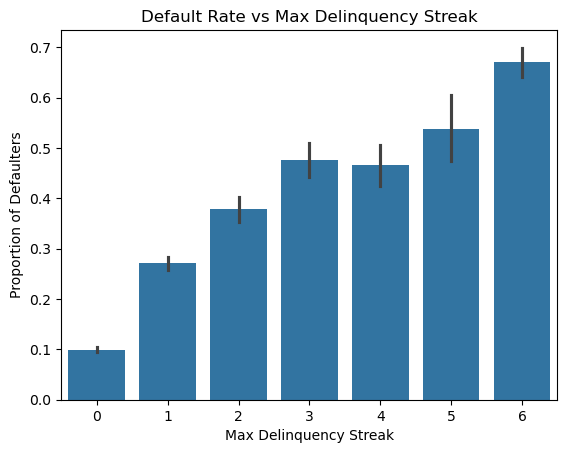

In [501]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.barplot(x='max_delinquency_streak',y='next_month_default',data = df)
plt.xlabel('Max Delinquency Streak')
plt.ylabel('Proportion of Defaulters')
plt.title('Default Rate vs Max Delinquency Streak')
plt.show()




In [502]:
print(df['PAY_TO_BILL_ratio'].describe())
print(df['PAY_TO_BILL_ratio'].unique())


count    25247.000000
mean         0.148018
std          5.024064
min       -546.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        205.000000
Name: PAY_TO_BILL_ratio, dtype: float64
[   0    2    1   -1    3   13    7    6   12    4   18    5   19   -4
    8   -3    9   -9   11 -121   58   10   29  -28   -7   14  -20   21
  -36   38   -2   23   24  -78   36 -375   26   -6   17 -546   62   -5
  -23   44   28  -12   31  -38   16  -11   67   15  121   48  -10 -249
   -8   50  -18   49  205   53  -34   39]


Higher credit utilisation is slightly associated with a greater likelihood of default.But it’s not a strong discriminator alone, whereas in "gender vs Default Status" graph -> gender is a strong predictor of default which shows chances of female as defaulter is more than male

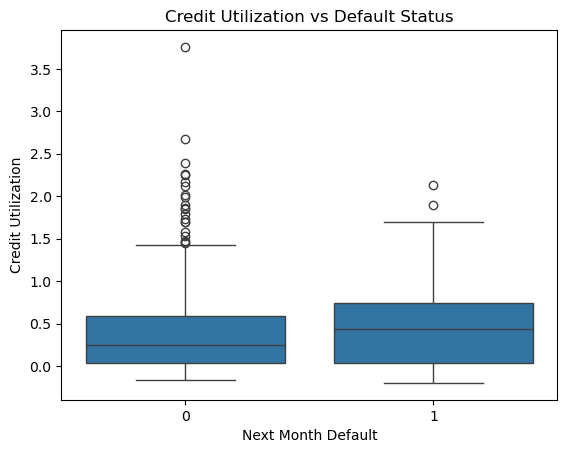

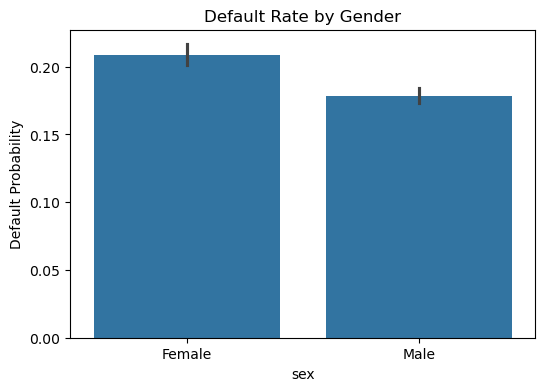

In [503]:
sns.boxplot(x='next_month_default', y='credit_utilization', data=df)
plt.title('Credit Utilization vs Default Status')
plt.xlabel('Next Month Default')
plt.ylabel('Credit Utilization')
plt.show()
# df['sex'] = credit_df['sex']
plt.figure(figsize=(6,4))
sns.barplot(x='sex', y='next_month_default', data=df, estimator=lambda x: sum(x)/len(x))
plt.xticks([0, 1], ['Female', 'Male'])
plt.title('Default Rate by Gender')
plt.ylabel('Default Probability')
df = pd.get_dummies(df, columns=['sex'], drop_first=True)



In [504]:
df

,LIMIT_BAL,age,pay_0,pay_2,pay_3,pay_4,pay_5,pay_6,Bill_amt1,Bill_amt2,...,marriage_2,marriage_3,education_2,education_3,education_4,credit_utilization,max_delinquency_streak,age_group_senior,age_group_old,sex_1
0,60000,25.0,2,2,2,0,0,0,60323,60728,...,1,0,1,0,0,0.691850,3,False,False,False
1,290000,24.0,0,0,-2,-2,-1,0,11157,0,...,1,0,0,0,0,0.008738,0,False,False,True
2,180000,60.5,0,0,0,0,0,0,47930,48921,...,0,0,1,0,0,0.280122,0,False,True,False
3,210000,43.0,0,0,0,0,0,0,91152,92916,...,0,0,1,0,0,0.410614,0,True,False,True
4,280000,32.0,-2,-2,-2,-2,-2,-2,19666,999,...,1,0,0,0,0,0.042193,0,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25242,90000,33.0,0,0,0,0,2,2,75452,76395,...,0,0,1,0,0,0.914578,2,False,False,True
25243,60000,49.0,0,0,0,0,0,0,59578,66780,...,0,0,1,0,0,0.689517,0,True,False,False
25244,120000,31.0,-1,-1,-1,-1,-1,-1,1315,1315,...,1,0,0,0,0,0.025592,0,False,False,False
25245,390000,40.0,0,0,0,0,0,0,163031,155854,...,0,0,0,0,1,0.347570,0,False,False,True


For the feature `AGE`, we perform a similar visual analysis, as shown above on the right. The probability of non-default of age between approximately $25$ and $40$ is higher, which indicates that consumers in this age group are more capable of repaying credit card loans

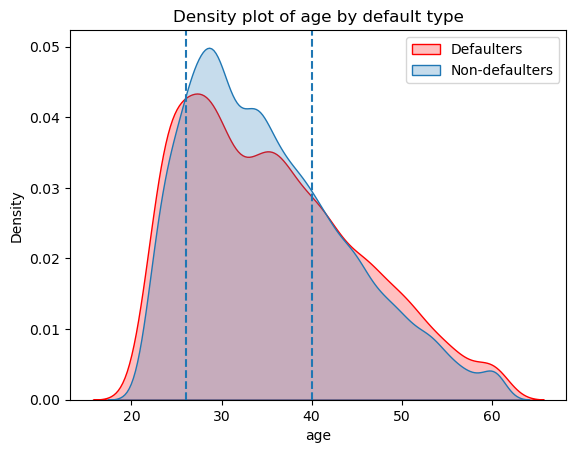

In [505]:
class_0 = df.loc[df['next_month_default'] == 0]['age']
class_1 = df.loc[df['next_month_default'] == 1]['age']


plt.title('Density plot of age by default type')

sns.kdeplot(class_1, fill=True, label='Defaulters', color='red')
sns.kdeplot(class_0, fill=True, label='Non-defaulters')

plt.axvline(26, 0, ls='--')
plt.axvline(40, 0, ls='--')
plt.legend()

plt.show()

To train the model, we need two different variables: one (x_train) for training the model and the other (y_train) to compare the model's predictions to actual outcomes.

In [506]:
y_train = df['next_month_default']
y_train.shape

(25247,)

In [507]:
x_train = df.drop('next_month_default',axis = 1)
x_train.shape

(25247, 32)

# Model Evaluation

Often, Credit default detection data is imbalanced, to balance it out, i performed SMOTE on the training data & then i split the dataset into two to see how model perform on unseen data

In [508]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x_train, y_train, test_size=0.2, random_state=42, shuffle=True)

smote = SMOTE(sampling_strategy=0.6, random_state=42)
x_train, y_train = smote.fit_resample(x_train, y_train)

print(x_train.shape)
print(y_train.shape)


(26152, 32)
(26152,)


We scale selected numeric columns using StandardScaler so they all have a similar range (mean = 0, std = 1).
This helps machine learning models perform better by treating all features equally.

In [509]:
from tensorflow import keras
from sklearn.preprocessing import  StandardScaler
columns_to_normalize = [
    'LIMIT_BAL', 'age',
    'pay_0', 'pay_2', 'pay_3', 'pay_4', 'pay_5', 'pay_6',
    'Bill_amt1', 'Bill_amt2', 'Bill_amt3', 'Bill_amt4', 'Bill_amt5', 'Bill_amt6',
    'pay_amt1', 'pay_amt2', 'pay_amt3', 'pay_amt4', 'pay_amt5', 'pay_amt6',
    'AVG_Bill_amt'
]
scaler = StandardScaler()
x_train[columns_to_normalize] = scaler.fit_transform(x_train[columns_to_normalize])
x_test[columns_to_normalize] = scaler.transform(x_test[columns_to_normalize])





In [510]:
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

models = {
    #logistic regression
    'lr': LogisticRegression(class_weight = 'balanced',max_iter = 1000,random_state = 42),
    #MLPClassifier
    'mlp' : MLPClassifier(hidden_layer_sizes=(26, 30, 15),activation='relu', solver='adam',alpha=0.0001, batch_size=32, 
                            learning_rate_init=0.01, max_iter=20,random_state=42, verbose=True),
     #RandomForest
     'rf': RandomForestClassifier( n_estimators=200,max_depth=15, min_samples_split=10, min_samples_leaf=5,class_weight='balanced',
                                random_state=42),  
      #XGBClassifier
      'xgb':XGBClassifier(n_estimators = 800,learning_rate = 0.05)
}
 
        


This function finds the best cutoff point for prediction by testing different values and picking the one with the highest F2 score (which focuses more on recall). It returns the best threshold and the final predictions based on it.

In [511]:
from sklearn.metrics import f1_score,fbeta_score,accuracy_score,classification_report,confusion_matrix
def tresh_reslt(model,x_test,y_test):
    thresholds = np.arange(0.1,0.91,0.05)
    y_proba = model.predict_proba(x_test)[:,1]
    results = []
    for threshold in thresholds:
        y_pred = (y_proba>=threshold).astype(int)
        f1 = f1_score(y_test,y_pred)
        f2 = fbeta_score(y_test,y_pred,beta = 2)
        results.append({'threshold':threshold,'f1_score':f1,'f2_score':f2})
    result_df = pd.DataFrame(results)
    best_row = result_df.loc[result_df['f2_score'].idxmax()]
    best_threshold = best_row['threshold']
    best_f2 = best_row['f2_score']
    return best_threshold,(y_proba>=best_threshold).astype(int)
    
    
    
    
    

Model Training and Evaluation
This function trains four models (Logistic Regression, MLP, Random Forest, and XGBoost) using the training data. After training, it evaluates each model on the test set using the best threshold based on F2 score. It returns accuracy, F1, F2, confusion matrix, and a full classification report for each model.

In [512]:
def model_train(models,x_train,y_train,x_test,y_test):
    results = {}
    model_names = ['lr','mlp','rf','xgb']
    for mod in model_names:
        model = models[mod]
        model.fit(x_train,y_train)
        threshold,y_pred = tresh_reslt(model,x_test,y_test)
        results[mod] = { 'threshold':threshold,
                         'accuracy' : accuracy_score(y_test,y_pred),
                         'f1_score' : f1_score(y_test,y_pred),
                         'f2_score'  : fbeta_score(y_test,y_pred,beta=2),                   
                         "confusion_matrix" :confusion_matrix(y_test,y_pred),
                        "Classification report" : classification_report(y_test,y_pred)
         }
                        
    return results
        






        
    

In [513]:
results = model_train(models,x_train,y_train,x_test,y_test)

# for i in results:
#     print(results[i])
for model_name, metrics in results.items():
    print(f"\n=== Results for {model_name.upper()} ===")
    print(f"Optimal Threshold: {metrics['threshold']:.2f}")
    print(f"Accuracy: {metrics['accuracy']:.3f}")
    print(f"F1 Score: {metrics['f1_score']:.3f}")
    print(f"F2 Score: {metrics['f2_score']:.3f}")
    print("Confusion Matrix:")
    print(metrics['confusion_matrix'])
    print("Classification Report:")
    print(metrics['Classification report'])
   


Iteration 1, loss = 0.50802985
Iteration 2, loss = 0.47713582
Iteration 3, loss = 0.46810662
Iteration 4, loss = 0.46252414
Iteration 5, loss = 0.45804852
Iteration 6, loss = 0.45245328
Iteration 7, loss = 0.44874201
Iteration 8, loss = 0.44604404
Iteration 9, loss = 0.44103338
Iteration 10, loss = 0.43707446
Iteration 11, loss = 0.43722717
Iteration 12, loss = 0.43288303
Iteration 13, loss = 0.43212591
Iteration 14, loss = 0.43086020
Iteration 15, loss = 0.42825582
Iteration 16, loss = 0.43003163
Iteration 17, loss = 0.42519515
Iteration 18, loss = 0.42526648
Iteration 19, loss = 0.42706234
Iteration 20, loss = 0.42391396


/Users/indr/anaconda3/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(



=== Results for LR ===
Optimal Threshold: 0.25
Accuracy: 0.463
F1 Score: 0.376
F2 Score: 0.567
Confusion Matrix:
[[1522 2573]
 [ 138  817]]
Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.37      0.53      4095
           1       0.24      0.86      0.38       955

    accuracy                           0.46      5050
   macro avg       0.58      0.61      0.45      5050
weighted avg       0.79      0.46      0.50      5050


=== Results for MLP ===
Optimal Threshold: 0.15
Accuracy: 0.505
F1 Score: 0.399
F2 Score: 0.591
Confusion Matrix:
[[1718 2377]
 [ 124  831]]
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.42      0.58      4095
           1       0.26      0.87      0.40       955

    accuracy                           0.50      5050
   macro avg       0.60      0.64      0.49      5050
weighted avg       0.81      0.50      0.54      5050


=== Results for 

# Model Selection

In [514]:

f2_scores = {}
for i in results:
    f2_scores[i] = results[i]['f2_score']
f2_scores

{'lr': 0.5665742024965326,
 'mlp': 0.5912066021627774,
 'rf': 0.6128345498783455,
 'xgb': 0.592791182603515}

We selected the Random Forest model as the best performer. This code extracts its optimal threshold, accuracy, F1 score, and F2 score, then stores these metrics in a table for easy viewing.

In [515]:
best_model = models['rf']
best_threshold  = results['rf']['threshold']
best_model_result = results['rf']
metrics_dict = {
    'threshold': [best_model_result['threshold']],
    'accuracy': [best_model_result['accuracy']],
    'f1_score': [best_model_result['f1_score']],
    'f2_score': [best_model_result['f2_score']]
}
df_metrics = pd.DataFrame(metrics_dict)
print(df_metrics)


   threshold  accuracy  f1_score  f2_score
0       0.25  0.584356  0.434384  0.612835


# Same Processing & Feature Engineering for Validation Set

In [516]:
df2 = pd.read_csv('validate_dataset_final.csv')

df_with_id = pd.read_csv('validate_dataset_final.csv')



In [517]:

df2.drop('Customer_ID',axis='columns',inplace = True)

In [518]:
df2.isnull().sum()


marriage             0
sex                  0
education            0
LIMIT_BAL            0
age                  0
pay_0                0
pay_2                0
pay_3                0
pay_4                0
pay_5                0
pay_6                0
Bill_amt1            0
Bill_amt2            0
Bill_amt3            0
Bill_amt4            0
Bill_amt5            0
Bill_amt6            0
pay_amt1             0
pay_amt2             0
pay_amt3             0
pay_amt4             0
pay_amt5             0
pay_amt6             0
AVG_Bill_amt         0
PAY_TO_BILL_ratio    0
dtype: int64

In [519]:
col = ['marriage','education']

for i in col:
    print(f'{i} : {df2[i].unique()}')

df2['marriage']=df2['marriage'].replace({0:3})
df2['education'] = df2['education'].replace({0:4,5:4,6:4})

for i in col:
    print(f'{i} : {df2[i].unique()}')
del col
colums = df2.columns
cat_colms = ['marriage','education']
num_colms = [i for i in colums if i not in cat_colms]

df2 = pd.get_dummies(df2,columns= cat_colms ,drop_first = True ).astype(int)

marriage : [1 2 3 0]
education : [2 1 3 4 5 0 6]
marriage : [1 2 3]
education : [2 1 3 4]


In [520]:
def outlier_solution(df2,columns):
    for col in columns:
        Q1 = df2[col].quantile(0.25)
        Q3 = df2[col].quantile(0.75)
        iqr = Q3-Q1
        lower = Q1 - 1.5*iqr
        upper = Q3 + 1.5*iqr
        df2[col] = df2[col].clip(lower,upper)
    return df2
columns= ["age", "LIMIT_BAL",
    "Bill_amt1", "Bill_amt2", "Bill_amt3", "Bill_amt4", "Bill_amt5", "Bill_amt6",
    "pay_amt1", "pay_amt2", "pay_amt3", "pay_amt4", "pay_amt5", "pay_amt6",
    "AVG_Bill_amt"]
df2 = outlier_solution(df2,columns)
df2

Q1 = df2['PAY_TO_BILL_ratio'].quantile(0.25)
Q3 = df2['PAY_TO_BILL_ratio'].quantile(0.75)
iqr = Q3 - Q1
lower = Q1 - 1.5 * iqr
upper = Q3 + 1.5 * iqr
df2['PAY_TO_BILL_ratio'] = df2['PAY_TO_BILL_ratio'].clip(lower=0, upper=upper)
print(df2['PAY_TO_BILL_ratio'].describe())
print(df2['PAY_TO_BILL_ratio'].min())
print(df2['PAY_TO_BILL_ratio'].max())

count    5016.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
Name: PAY_TO_BILL_ratio, dtype: float64
0
0


In [521]:
bins = [21,40,50,61]
labels = ['adult','senior','old']
df2['age_group'] = pd.cut(df2['age'],bins = bins, labels = labels)
df2['credit_utilization'] = np.where(df2['LIMIT_BAL'] == 0, np.nan,
                                    df2['AVG_Bill_amt'] / df2['LIMIT_BAL'])
df2['credit_utilization'] = df2['credit_utilization'].fillna(df2['credit_utilization'].median())

df2['credit_utilization'].describe()

count    5016.000000
mean        0.350701
std         0.328258
min        -0.100000
25%         0.030113
50%         0.272273
75%         0.625191
max         2.117433
Name: credit_utilization, dtype: float64

In [522]:
delinquency_cols = [f'{i}' for i in ['pay_0','pay_2','pay_3','pay_4','pay_5','pay_6']]

delinquent_flags = df2[delinquency_cols].ge(1).astype(int)

def longest_streak(row):
    max_streak = streak = 0
    for val in row:
        if val == 1:
            streak += 1
            max_streak = max(max_streak, streak)
        else:
            streak = 0
    return max_streak
df2['max_delinquency_streak'] = delinquent_flags.apply(longest_streak, axis=1)
df2 = pd.get_dummies(df2, columns=['sex'], drop_first=True)
df2

,LIMIT_BAL,age,pay_0,pay_2,pay_3,pay_4,pay_5,pay_6,Bill_amt1,Bill_amt2,...,PAY_TO_BILL_ratio,marriage_2,marriage_3,education_2,education_3,education_4,age_group,credit_utilization,max_delinquency_streak,sex_1
0,220000,32.0,0,0,0,0,0,0,28853.000,29144.000,...,0,0,0,1,0,0,adult,0.106618,0,True
1,350000,35.0,-1,-1,-1,0,0,0,4438.000,33718.000,...,0,1,0,0,0,0,adult,0.039029,0,False
2,310000,39.0,0,0,0,0,0,0,164096.625,155533.125,...,0,1,0,0,0,0,adult,0.432502,0,True
3,20000,47.0,0,0,0,2,2,2,10628.000,11650.000,...,0,0,0,1,0,0,senior,0.666650,3,False
4,500000,30.0,0,0,0,0,0,0,98617.000,73464.000,...,0,1,0,1,0,0,adult,0.154408,0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5011,240000,51.0,0,0,0,0,0,0,98588.000,100544.000,...,0,0,0,1,0,0,old,0.432237,0,False
5012,60000,33.0,0,0,0,0,0,0,57560.000,57765.000,...,0,0,0,0,1,0,adult,0.697633,0,True
5013,290000,36.0,1,-2,-1,-1,0,0,0.000,0.000,...,0,0,0,0,0,0,adult,0.029245,1,False
5014,120000,28.0,0,0,0,0,0,0,103675.000,96833.000,...,0,0,0,1,0,0,adult,0.704100,0,True


In [523]:
df2 = pd.get_dummies(df2,columns = ['age_group'],drop_first=True)
df2

,LIMIT_BAL,age,pay_0,pay_2,pay_3,pay_4,pay_5,pay_6,Bill_amt1,Bill_amt2,...,marriage_2,marriage_3,education_2,education_3,education_4,credit_utilization,max_delinquency_streak,sex_1,age_group_senior,age_group_old
0,220000,32.0,0,0,0,0,0,0,28853.000,29144.000,...,0,0,1,0,0,0.106618,0,True,False,False
1,350000,35.0,-1,-1,-1,0,0,0,4438.000,33718.000,...,1,0,0,0,0,0.039029,0,False,False,False
2,310000,39.0,0,0,0,0,0,0,164096.625,155533.125,...,1,0,0,0,0,0.432502,0,True,False,False
3,20000,47.0,0,0,0,2,2,2,10628.000,11650.000,...,0,0,1,0,0,0.666650,3,False,True,False
4,500000,30.0,0,0,0,0,0,0,98617.000,73464.000,...,1,0,1,0,0,0.154408,0,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5011,240000,51.0,0,0,0,0,0,0,98588.000,100544.000,...,0,0,1,0,0,0.432237,0,False,False,True
5012,60000,33.0,0,0,0,0,0,0,57560.000,57765.000,...,0,0,0,1,0,0.697633,0,True,False,False
5013,290000,36.0,1,-2,-1,-1,0,0,0.000,0.000,...,0,0,0,0,0,0.029245,1,False,False,False
5014,120000,28.0,0,0,0,0,0,0,103675.000,96833.000,...,0,0,1,0,0,0.704100,0,True,False,False


In [524]:
columns_to_normalize = [
    'LIMIT_BAL', 'age',
    'pay_0', 'pay_2', 'pay_3', 'pay_4', 'pay_5', 'pay_6',
    'Bill_amt1', 'Bill_amt2', 'Bill_amt3', 'Bill_amt4', 'Bill_amt5', 'Bill_amt6',
    'pay_amt1', 'pay_amt2', 'pay_amt3', 'pay_amt4', 'pay_amt5', 'pay_amt6',
    'AVG_Bill_amt'
]
x_val = df2

x_val[columns_to_normalize] = scaler.transform(x_val[columns_to_normalize])





In [526]:
x_val = x_val[x_train.columns]
customer_ids = df_with_id.loc[x_val.index, 'Customer_ID']
y_proba = best_model.predict_proba(x_val)[:, 1]
y_pred_classes = (y_proba > best_threshold).astype(int)


submission = pd.DataFrame({
    'Customer_ID': customer_ids, 
    'next_month_default': y_pred_classes.ravel()
})
submission.to_csv("submission_<23124010>.csv", index=False)



